# Synthesis Extraction Pipeline Example

This notebook demonstrates the complete pipeline for extracting structured synthesis procedures from scientific papers.

## Pipeline Overview

The extraction pipeline follows these steps:

```
PDF (bytes)
    ↓
[1. PDF Extraction] → Markdown text + embedded figures (base64)
    ↓
[2. Figure Extraction] → List of FigureInfo objects (segmented, classified)
    ↓
[3. Text Cleaning] → Clean text (remove figures & references)
    ↓
[4. Material Extraction] → List of synthesized materials
    ↓
[5. Synthesis Extraction] → GeneralSynthesisOntology objects (per material)
```

## Prerequisites

Before running this notebook, ensure you have:

1. **Installed the package**: `pip install -e .` from the repository root
2. **Set up environment variables** in a `.env` file:
   - `MISTRAL_API_KEY` (if using Mistral PDF extraction)
   - `OPENAI_API_KEY` (if using OpenAI models)
   - `GOOGLE_API_KEY` (if using Gemini models)
3. **Prepared your PDF files** in a data directory

---
## Setup and Imports

In [2]:
import base64
import io
import warnings


import dotenv
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import Markdown, display
from PIL import Image as PILImage

# Load environment variables from .env file
dotenv.load_dotenv()

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

In [3]:
import sys
print(sys.executable)
print(sys.path)

/Users/valeriegentzke/Documents/Studieren/lemat_synth/lematerial-llm-synthesis/.venv/bin/python
['/Users/valeriegentzke/.local/share/uv/python/cpython-3.11.14-macos-aarch64-none/lib/python311.zip', '/Users/valeriegentzke/.local/share/uv/python/cpython-3.11.14-macos-aarch64-none/lib/python3.11', '/Users/valeriegentzke/.local/share/uv/python/cpython-3.11.14-macos-aarch64-none/lib/python3.11/lib-dynload', '', '/Users/valeriegentzke/Documents/Studieren/lemat_synth/lematerial-llm-synthesis/.venv/lib/python3.11/site-packages', '/Users/valeriegentzke/Documents/Studieren/lemat_synth/lematerial-llm-synthesis/src']


### Configuration

Set your paper details and data directory here:

In [4]:
# Configure your paper details
PAPER_NAME = "02_Itoh_2002_Hydrogen"  # PDF filename without .pdf extension
PAPER_ID = "02_Itoh_2002_Hydrogen"  # Unique identifier for the paper
SUPPL_NAME = None  # No supporting information for test

# Directory containing the PDF files
DATA_DIR = "../../data/pdf_papers/"

In [5]:
import os
from pathlib import Path

# Configure your paper details
PAPER_NAME = "02_Itoh_2002_Hydrogen"  # PDF filename without .pdf extension
PAPER_ID = "02_Itoh_2002_Hydrogen"  # Unique identifier for the paper
SUPPL_NAME = "02_Itoh_2002_Hydrogen" # No supporting information for test

# Get the notebook's directory and build path from there
NOTEBOOK_DIR = Path(os.getcwd())
# If running from repo root, use examples/data/pdf_papers/
# If running from notebook dir, use ../../data/pdf_papers/
if (NOTEBOOK_DIR / "examples" / "data" / "pdf_papers").exists():
    DATA_DIR = str(NOTEBOOK_DIR / "examples" / "data" / "pdf_papers") + "/"
else:
    DATA_DIR = str(NOTEBOOK_DIR / ".." / ".." / "data" / "pdf_papers") + "/"

print(f"Using DATA_DIR: {DATA_DIR}")


Using DATA_DIR: /Users/valeriegentzke/Documents/Studieren/lemat_synth/lematerial-llm-synthesis/examples/notebooks/dev/../../data/pdf_papers/


---
## Step 1: PDF Extraction

Extract text and figures from PDF files. Two implementations are available:

| Extractor | Pros | Cons |
|-----------|------|------|
| **DoclingPDFExtractor** | Free, open-source, no API key needed | May be slower |
| **MistralPDFExtractor** | Advanced OCR, better quality | Requires API key |

Both extractors implement the `PdfExtractorInterface` and return markdown text with embedded base64 images.

### Option A: Using MistralPDFExtractor (Recommended for quality)

Requires `MISTRAL_API_KEY` environment variable or passed as argument.

In [6]:

from llm_synthesis.transformers.pdf_extraction import MistralPDFExtractor

# Initialize the PDF extractor
pdf_extractor = MistralPDFExtractor(
    structured=False  # Set True to get JSON structure instead of markdown
)

# Extract main paper
with open(DATA_DIR + PAPER_NAME + ".pdf", "rb") as f:
    pdf_data = f.read()

paper_markdown = pdf_extractor.forward(pdf_data)
print(f"Extracted {len(paper_markdown)} characters from main paper")

Extracted 362564 characters from main paper


In [7]:
# Extract supporting information (if available)
try:
    with open(DATA_DIR + SUPPL_NAME + ".pdf", "rb") as f:
        suppl_pdf_data = f.read()
    si_markdown = pdf_extractor.forward(suppl_pdf_data)
    print(f"Extracted {len(si_markdown)} characters from SI")
except FileNotFoundError:
    si_markdown = ""
    print("No supporting information file found")

Extracted 362555 characters from SI


### Option B: Using DoclingPDFExtractor (Free, no API key)

Uncomment and run this cell if you prefer the open-source option:

In [8]:
# from llm_synthesis.transformers.pdf_extraction import DoclingPDFExtractor
#
# pdf_extractor = DoclingPDFExtractor(
#     pipeline="standard",  # or "fast" for quicker processing
#     table_mode="accurate",
#     use_gpu=True,
#     format="markdown"
# )
#
# with open(DATA_DIR + PAPER_NAME + ".pdf", "rb") as f:
#     paper_markdown = pdf_extractor.forward(f.read())

### Preview the extracted text

In [9]:
# Display first 2000 characters of the extracted markdown
display(Markdown(paper_markdown[:5000] + "\n\n...[truncated]"))

Materials Transactions, Vol. 43, No. 11 (2002) pp. 2763 to 2767

Special Issue on Protium New Function in Materials

©2002 The Japan Institute of Metals

# Hydrogen Generation by Ammonia Cracking with Iron Metal-Rare Earth Oxide Composite Catalyst

Masahiro Itoh, Masahiro Masuda *1 and Ken-ichi Machida *2

Collaborative Research Center for Advanced Science and Technology, Osaka University, Suita 565-0871, Japan

A series of fine powders of $\mathrm{Fe - MO}_x$ ($\mathrm{M} = \mathrm{Ce}$, Al, Si, Sr, and Zr) composite were prepared by the conventional coprecipitation method from their nitrate solutions. The activity of hydrogen extraction from ammonia over these composite powders as ammonia cracking catalyst was characterized. The catalytic activity for ammonia decomposition observed on the composite powders of $\mathrm{Fe - (Ce,Zr)O_2}$ was high because of the electron donation to the iron metal from $\mathrm{Ce^{3+}}$ due to the reduction of $\mathrm{CeO_2}$ through the reaction. In addition to this effect, the additive $(\mathrm{Ce},\mathrm{Zr})\mathrm{O}_2$ solid solution supports worked as a solid acid to enhance the ammonia adsorption and reaction probability of Fe component. These were effective to generate hydrogen through the ammonia decomposition at relatively low temperature.

(Received May 20, 2002; Accepted July 8, 2002)

**Keywords**: hydrogen generation, ammonia decomposition, metal-metal oxide composite, ammonia decomposition catalyst, solid acid, ammonia regeneration

# 1. Introduction

Hydrogen has been regarded as the new energy source because of its cleanliness, fast energy cycle, convenience of energy conversion, and so on. In the automobile industry, the polyelectrolyte membrane fuel cells car has been attractively developed. For the movable instruments, especially automobile, with on-board type, one of the main problems is of hydrogen supply. The ways of hydrogen supply to the fuel cell on the removable instruments are proposed by using liquid hydrogen directly, hydrogen storage materials, or reformation of chemical hydrides such as hydrocarbon. For the case of hydrocarbon reforming, there still remains the problem of poisoning reforming catalyst by CO generated as byproduct of the reaction. On the other hand, ammonia is also hydrogen rich compound of which the hydrogen content reaches to about $17\mathrm{mass}\%$. This value is higher than that of methanol $(12.5\mathrm{mass}\%)$, which is regarded as the promising candidate of hydrogen sources for PEMFCs car. Some studies about ammonia as hydrogen reservoir were performed.$^{1-4)}$ They reported that ammonia is better than methanol for energy efficiency for alkaline fuel cell.

In our previous study,$^{5-8)}$ rare earth or transition metal-iron intermetallic compounds were found to be the good nitrogen absorbing materials from the characteristics of nitrogen absorption-desorption. In using ammonia as nitrogen source, hydrogen is also generated as byproduct according to the below reaction.

$$
\mathrm{M} + \mathrm{NH}_3 \rightarrow \mathrm{MN}_x + (1 - x) / 2\mathrm{N}_2 + 3 / 2\mathrm{H}_2 \tag{1}
$$

During the investigation about nitrogen absorbing materials, it has been also found that Fe can easily absorb and desorb nitrogen when ammonia is used as nitrogen source. Nitrogen in the metal nitrides exists as an atomic state in the lattice, and nitrogen desorbed from the metal nitrides has a considerably high reactivity. In fact, we confirmed the ammonia

regeneration at about $100\%$ of yield in the reaction between the desorbed nitrogen and hydrogen.$^{5-8)}$ However, such intermetallic compounds or Fe have little surface area due to the aggregation of powder particles during reactions, and there still remains the problem of the slow reaction rate between the metal surface and ammonia for ammonia decomposition.

In this study, a series of composite powders between Fe and $\mathrm{MO}_x$ ($\mathrm{M} = \mathrm{Ce}, \mathrm{Al}, \mathrm{Si}, \mathrm{Sr}, \mathrm{Zr}$) were prepared by coprecipitation method. The hybridization between Fe and $\mathrm{MO}_x$ aims to suppress the aggregation of powders during reactions and to enhance the surface area, because the additive oxide is expected to retard the crystal growth of iron particle. Especially, $\mathrm{CeO}_2$ has been practically used as promoter of the automotive exhaust three-way catalyst for the ability of oxygen absorption and desorption due to its nonstoichiometry of oxygen.$^{9,10)}$ The catalytic activity of ammonia decomposition (hydrogen extraction from ammonia) was investigated from the viewpoint of the metal-support interaction and the solid acidity of additive oxides. Further, the nitrogen absorption-desorption properties on the $\mathrm{Fe - MO}_x$ composite powders were also examined.

# 2. Experimental

The composite powder of $\mathrm{Fe - CeO_2}$ with a metal ratio of $\mathrm{Fe / Ce} = 5 / 1$ was prepared by the coprecipitation method from their nitrate solution

...[truncated]

### Save extracted markdown for later use

In [10]:
# Save the extracted markdown
with open(DATA_DIR + PAPER_NAME + ".md", "w", errors="replace") as f:
    f.write(paper_markdown)

if si_markdown:
    with open(DATA_DIR + SUPPL_NAME + ".md", "w", errors="replace") as f:
        f.write(si_markdown)

print(f"Saved markdown files to {DATA_DIR}")

Saved markdown files to /Users/valeriegentzke/Documents/Studieren/lemat_synth/lematerial-llm-synthesis/examples/notebooks/dev/../../data/pdf_papers/


---
## Step 2: Figure Extraction

Extract figures from the markdown text. Figures are embedded as base64 data URIs.

Two segmentation backends are available:

| Backend | Model(s) | Output | Pros | Cons |
|---------|----------|--------|------|------|
| **DINO** (default) | Grounding DINO + ResNet-152 | 28 figure classes | More granular classification | Requires 2 models |
| **Florence** | Florence-2 + LoRA | "quantitative plot" / "qualitative plot" | Single model, end-to-end | Binary classification only |

Each extracted figure includes:
- `base64_data`: The image data
- `figure_class`: Classification label
- `quantitative`: Whether it's a quantitative figure (plot, chart, etc.)
- `context_before` / `context_after`: Surrounding text for context
- `figure_reference`: Reference like "Figure 2a"

In [11]:
from llm_synthesis.transformers.figure_extraction import FigureExtractorMarkdown

# ============================================================================
# Option A: Florence-2 with LoRA - single model for detection + classification
# ============================================================================
# Uses a fine-tuned Florence-2 model from HuggingFace Hub
# Outputs: "quantitative plot" or "qualitative plot"
# Model: https://huggingface.co/amayuelas/plot-visualization-florence-2-lora-32

# Uncomment to use Florence instead:
figure_extractor_florence = FigureExtractorMarkdown(
    segmenter="florence",
    florence_repo_id="amayuelas/plot-visualization-florence-2-lora-32",
)
figures = figure_extractor_florence.forward(paper_markdown)
print(f"Found {len(figures)} figures in the paper (using Florence-2)")

# You can also use a custom LoRA adapter:
# figure_extractor_custom = FigureExtractorMarkdown(
#     segmenter="florence",
#     florence_repo_id="your-username/your-lora-adapter"
# )

Loading Florence-2 base model: microsoft/Florence-2-base-ft
Loading LoRA adapters from: amayuelas/plot-visualization-florence-2-lora-32
Merging LoRA adapters with base model...
Florence-2 model loaded on mps
Found 9 figures in the paper.
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Found 9 figures in the paper (using Florence-2)


In [12]:
# # ============================================================================
# # Option B: DINO + ResNet (default) - 28 figure classes
# # ============================================================================
# # Uses Grounding DINO for segmentation and ResNet-152 for classification
# # Provides granular figure types: "Bar plots", "Scatter plot", "Microscopy", etc.

# figure_extractor = FigureExtractorMarkdown(segmenter="dino")

# # Extract figures from the markdown
# figures = figure_extractor.forward(paper_markdown)

# print(f"Found {len(figures)} figures in the paper (using DINO + ResNet)")

### Visualize extracted figures

Figure 1: Not Quantitative - Class: unknown
Reference: Fig. 2


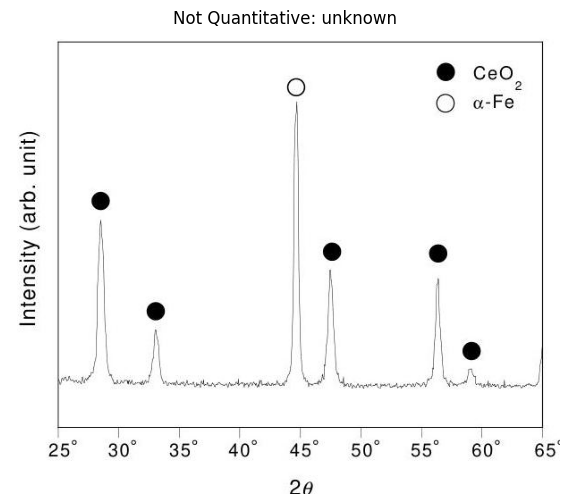

Figure 2: Not Quantitative - Class: qualitative plot
Reference: Unknown Figure


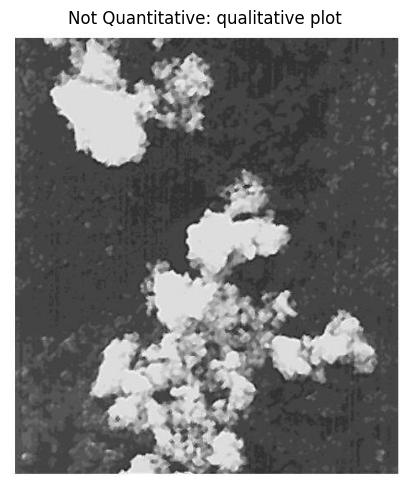

Figure 3: Not Quantitative - Class: qualitative plot
Reference: Unknown Figure


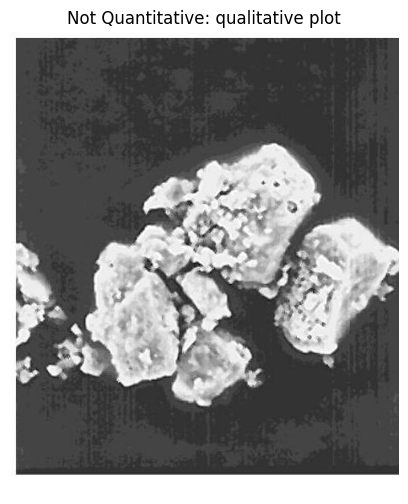

Figure 4: Not Quantitative - Class: unknown
Reference: Fig. 2


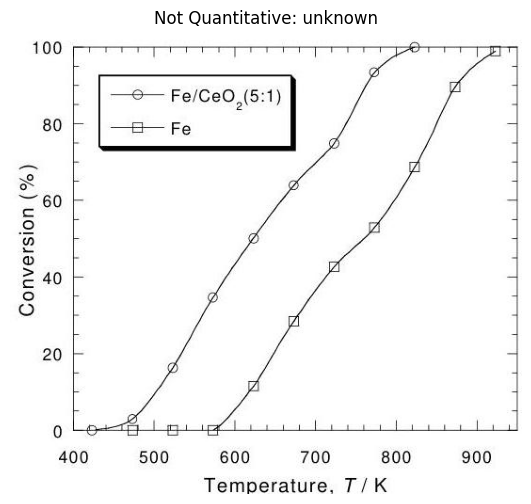

Figure 5: Not Quantitative - Class: unknown
Reference: Fig. 3


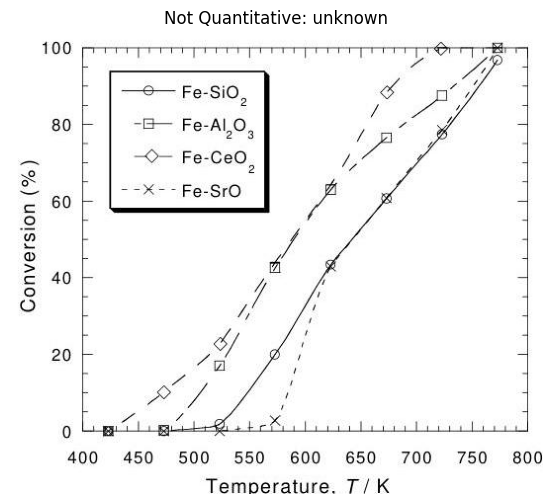

Figure 6: Not Quantitative - Class: unknown
Reference: Unknown Figure


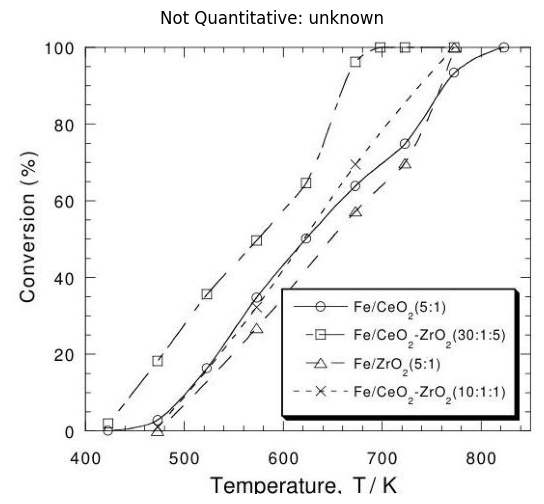

Figure 7: Not Quantitative - Class: unknown
Reference: Fig. 5


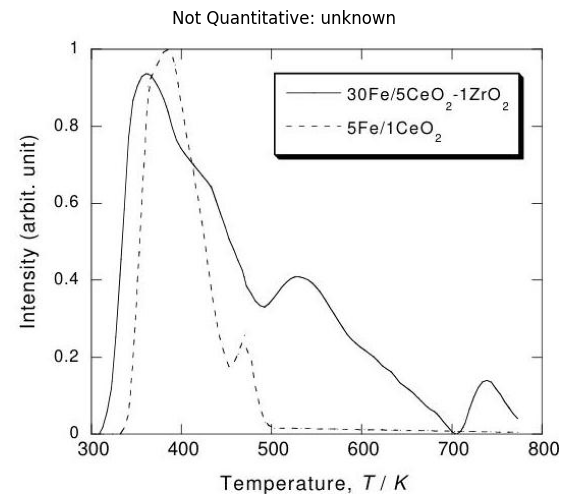

Figure 8: Not Quantitative - Class: unknown
Reference: Unknown Figure


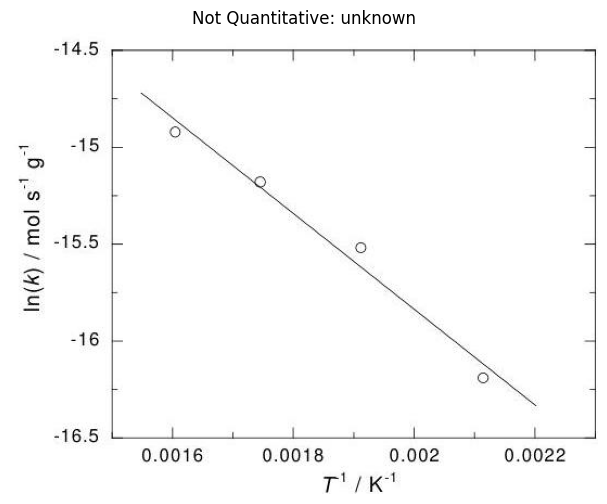

Figure 9: Not Quantitative - Class: unknown
Reference: Unknown Figure


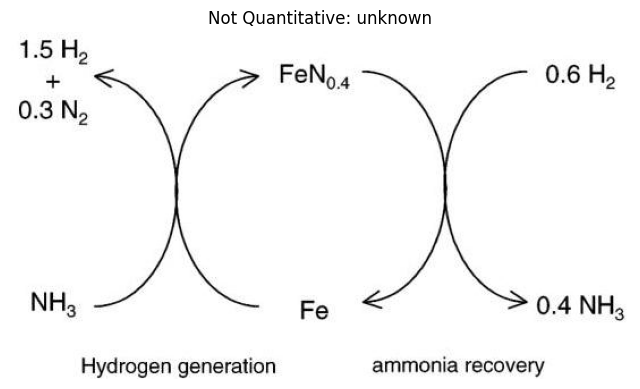

In [13]:
# Display all extracted figures with their classifications
for idx, figure in enumerate(figures):
    print("=" * 80)
    is_quantitative = (
        "Quantitative" if figure.quantitative else "Not Quantitative"
    )
    print(f"Figure {idx + 1}: {is_quantitative} - Class: {figure.figure_class}")
    print(f"Reference: {figure.figure_reference}")

    # Decode and display the image
    image_data = base64.b64decode(figure.base64_data)
    image = PILImage.open(io.BytesIO(image_data))

    plt.figure(figsize=(8, 6))
    plt.imshow(np.array(image))
    plt.axis("off")
    plt.title(f"{is_quantitative}: {figure.figure_class}")
    plt.show()

### Inspect figure metadata

In [14]:
# Print metadata for the first figure
if figures:
    fig = figures[0]
    print("Figure Reference:", fig.figure_reference)
    print("Figure Class:", fig.figure_class)
    print("Quantitative:", fig.quantitative)
    print("Position in text:", fig.position)
    print("\nAlt Text:", fig.alt_text[:200] if fig.alt_text else "None")
    print(
        "\nContext Before:",
        fig.context_before[:200] if fig.context_before else "None",
    )
    print(
        "\nContext After:",
        fig.context_after[:200] if fig.context_after else "None",
    )

Figure Reference: Fig. 2
Figure Class: unknown
Quantitative: False
Position in text: 8263

Alt Text: fig

Context Before: ^{-1}$ . The sole Fe powder prepared by the precipitation method had the surface area of only  $0.6\mathrm{m}^2\cdot \mathrm{g}^{-1}$ . It was also observed by SEM measurements that the sole Fe powder

Context After: ![fig](data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMj


---
## Step 3: Text Cleaning

Clean the extracted text by removing figures and references for better material/synthesis extraction.

Available utilities:
- `clean_text()`: Removes both figures and references
- `remove_figs()`: Removes only figure markdown
- `remove_references()`: Removes only reference sections

In [15]:
from llm_synthesis.utils.markdown_utils import clean_text

# Clean the paper text
clean_paper_text = clean_text(paper_markdown)
clean_si_text = clean_text(si_markdown) if si_markdown else ""

print(f"Original length: {len(paper_markdown)} characters")
print(f"Cleaned length: {len(clean_paper_text)} characters")
print(f"Removed: {len(paper_markdown) - len(clean_paper_text)} characters")

Original length: 362564 characters
Cleaned length: 25210 characters
Removed: 337354 characters


### Create Paper object

The `Paper` model holds the paper metadata and text content:

In [16]:
from llm_synthesis.models.paper import Paper

paper = Paper(
    id=PAPER_ID,
    name=PAPER_NAME,
    publication_text=clean_paper_text,
    si_text=clean_si_text,
)

print(f"Created Paper object: {paper.name} (ID: {paper.id})")

Created Paper object: 02_Itoh_2002_Hydrogen (ID: 02_Itoh_2002_Hydrogen)


---
## Step 4: Material Extraction

Extract the list of synthesized materials from the paper text using LLM-based extraction.

The extractor uses DSPy with configurable LLM backends:
- `gemini-2.0-flash`, `gemini-2.5-flash`, `gemini-2.5-pro` (Google)
- `gpt-4o`, `gpt-4o-mini` (OpenAI)
- `mistral-small`, `mistral-medium`, `mistral-large` (Mistral)

In [17]:
from llm_synthesis.transformers.material_extraction import (
    DspyTextExtractor,
    make_dspy_text_extractor_signature,
)
from llm_synthesis.utils.dspy_utils import get_llm_from_name

# Create a signature for material extraction
material_signature = make_dspy_text_extractor_signature(
    signature_name="TextToMaterials",
    instructions=(
        "Extract ONLY the final synthesized materials from the publication text. "
        "Focus on materials that were actually synthesized in the paper, not just mentioned. "
        "Return materials as chemical formulas when possible."
    ),
    input_description="The publication text to extract synthesized materials from.",
    output_name="materials",
    output_description=(
        "The final synthesized materials as a comma-separated list using chemical formulas "
        "(e.g., 'Ru/CeO2, Ni-Mo/Al2O3'). Never use common names alone."
    ),
)

# Initialize the LLM
material_lm = get_llm_from_name(
    llm_name="gemini-2.5-flash-lite",  # Fast and cost-effective
    model_kwargs={"temperature": 0.0},
)

# Create the material extractor
material_extractor = DspyTextExtractor(
    signature=material_signature,
    lm=material_lm,
)

In [18]:
# Extract materials from the paper
materials_text = material_extractor.forward(input=clean_paper_text)

# Parse the comma-separated list into individual materials
materials = [
    material.strip()
    for material in materials_text.replace("\n", ",").split(",")
    if material.strip()
]

print(f"Found {len(materials)} materials:")
for i, material in enumerate(materials, 1):
    print(f"  {i}. {material}")

2026/02/04 09:54:53 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.


Found 7 materials:
  1. Fe-CeO2
  2. Fe-Al2O3
  3. Fe-SiO2
  4. Fe-SrO
  5. Fe-ZrO2
  6. Fe-(Ce
  7. Zr)O2


---
## Step 5: Synthesis Extraction

Extract structured synthesis procedures for each material.

The output is a `GeneralSynthesisOntology` object containing:
- **target_compound**: The material being synthesized
- **target_compound_type**: Category (e.g., "nanomaterials", "ceramics")
- **synthesis_method**: Method used (e.g., "hydrothermal", "sol-gel")
- **starting_materials**: List of precursors with amounts
- **steps**: Ordered list of synthesis steps with conditions
- **equipment**: List of equipment used

**Note:** We use `gpt-4o-mini` here as it has better support for structured JSON outputs. 
Gemini models may fail with Pydantic validation errors for the enum fields.

In [ ]:
from llm_synthesis.transformers.synthesis_extraction import (
    DspySynthesisExtractor,
    make_dspy_synthesis_extractor_signature,
)

# System prompt to guide the model on valid enum values
SYNTHESIS_SYSTEM_PROMPT = """You are a helpful assistant that extracts structured synthesis procedures from scientific papers.

IMPORTANT: For the synthesis_method field, you MUST choose from these exact values:
'PVD', 'CVD', 'arc discharge', 'ball milling', 'spray pyrolysis', 'electrospinning', 
'sol-gel', 'hydrothermal', 'solvothermal', 'precipitation', 'coprecipitation', 'combustion', 
'microwave-assisted', 'sonochemical', 'template-directed', 'solid-state', 'flux growth', 
'float zone & Bridgman', 'arc melting & induction melting', 'spark plasma sintering', 
'electrochemical deposition', 'chemical bath deposition', 'liquid-phase epitaxy', 'self-assembly', 
'atomic layer deposition', 'molecular beam epitaxy', 'pulsed laser deposition', 'ion implantation', 
'lithographic patterning', 'wet impregnation', 'incipient wetness impregnation', 'mechanical mixing', 
'solution-based', 'mechanochemical', 'other'

For the target_compound_type field, you MUST choose from these exact values:
'metals & alloys', 'ceramics & glasses', 'polymers & soft matter', 'composites', 
'semiconductors & electronic', 'nanomaterials', 'two-dimensional materials', 
'framework & porous materials', 'biomaterials & biological', 'liquid materials', 
'hybrid & organic-inorganic', 'functional materials & catalysts', 'energy & sustainability', 
'smart & responsive materials', 'emerging & quantum materials', 'other'

If the exact method is not in the list, use the closest match or 'other'."""

# Create a signature for synthesis extraction
synthesis_signature = make_dspy_synthesis_extractor_signature(
    signature_name="ExtractStructuredSynthesis",
    instructions=(
        "Extract the complete structured synthesis procedure for the specified material. "
        "Include all steps, conditions (temperature, time, atmosphere), equipment, and precursors. "
        "Be thorough and preserve all quantitative details."
    ),
    paper_text_description="The complete paper text containing synthesis procedures.",
    material_name_description="The specific material to extract the synthesis procedure for.",
    output_name="structured_synthesis",
    output_description="The complete structured synthesis procedure for the material.",
)

# Initialize the LLM - use gpt-4o-mini for better structured output support
synthesis_lm = get_llm_from_name(
    llm_name="gemini-2.0-flash",  # Better structured output support than Gemini"gemini-2.5-flash"
    model_kwargs={
        "temperature": 0.0,
        "max_tokens": 8000,
    },
    system_prompt=SYNTHESIS_SYSTEM_PROMPT,
)

# Create the synthesis extractor
synthesis_extractor = DspySynthesisExtractor(
    signature=synthesis_signature,
    lm=synthesis_lm,
)

: 

In [ ]:
from llm_synthesis.models.paper import SynthesisEntry

# Extract synthesis for each material
all_syntheses = []

for material in materials:
    print(f"\nExtracting synthesis for: {material}")
    print("-" * 50)

    try:
        # The extractor takes a tuple of (paper_text, material_name)
        synthesis = synthesis_extractor.forward(
            input=(clean_paper_text, material)
        )

        # Store the result
        all_syntheses.append(
            SynthesisEntry(
                material=material,
                synthesis=synthesis,
                evaluation=None,  # Optional: add judge evaluation
            )
        )

        print(f"  Method: {synthesis.synthesis_method}")
        print(f"  Type: {synthesis.target_compound_type}")
        print(f"  Steps: {len(synthesis.steps)}")
        print(f"  Starting materials: {len(synthesis.starting_materials)}")

    except Exception as e:
        print(f"  Error: {e}")

print(f"\nSuccessfully extracted {len(all_syntheses)} synthesis procedures")

2026/02/03 11:16:39 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.



Extracting synthesis for: Ni/SiO2
--------------------------------------------------


2026/02/03 11:16:50 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.


  Method: wet impregnation
  Type: functional materials & catalysts
  Steps: 8
  Starting materials: 3

Extracting synthesis for: Co/SiO2
--------------------------------------------------


2026/02/03 11:17:00 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.


...

2026/02/03 11:17:21 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.


  Method: wet impregnation
  Type: functional materials & catalysts
  Steps: 8
  Starting materials: 4

Extracting synthesis for: Ni3Co7/SiO2
--------------------------------------------------


2026/02/03 11:17:29 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.


  Method: wet impregnation
  Type: functional materials & catalysts
  Steps: 8
  Starting materials: 4

Extracting synthesis for: Ni5Co5/SiO2-K
--------------------------------------------------
  Method: wet impregnation
  Type: functional materials & catalysts
  Steps: 8
  Starting materials: 5

Successfully extracted 6 synthesis procedures


: 

### Inspect a synthesis result

In [ ]:
# Display the first synthesis in detail
if all_syntheses:
    synthesis = all_syntheses[0].synthesis

    print(f"Target Compound: {synthesis.target_compound}")
    print(f"Compound Type: {synthesis.target_compound_type}")
    print(f"Synthesis Method: {synthesis.synthesis_method}")

    print("\nStarting Materials:")
    for mat in synthesis.starting_materials:
        print(f"  - {mat.name}: {mat.amount} {mat.unit}")

    print("\nSynthesis Steps:")
    for step in synthesis.steps:
        print(f"  {step.step_number}. {step.action}")
        if step.conditions:
            if step.conditions.temperature:
                print(
                    f"      Temperature: {step.conditions.temperature} {step.conditions.temp_unit}"
                )
            if step.conditions.duration:
                print(
                    f"      Duration: {step.conditions.duration} {step.conditions.time_unit}"
                )

    print("\nEquipment:")
    for eq in synthesis.equipment:
        print(f"  - {eq.name}")

Target Compound: Ni/SiO2
Compound Type: functional materials & catalysts
Synthesis Method: wet impregnation

Starting Materials:
  - fumed SiO2: 0.9 g
  - deionized water: 50.0 mL
  - Ni(NO3)2·7H2O: None M

Synthesis Steps:
  1. mix
  2. add
  3. sonicate
      Duration: 30.0 min
  4. stir
      Temperature: 30.0 °C
      Duration: 12.0 h
  5. heat
      Temperature: 80.0 °C
  6. dry
      Temperature: 80.0 °C
      Duration: 12.0 h
  7. filter
  8. reduce
      Temperature: 550.0 °C
      Duration: 1.0 h

Equipment:
  - beaker
  - water bath
  - magnetic stirrer
  - ultrasonicator
  - oven
  - tube furnace
  - sieve


: 

### Export synthesis as JSON

In [ ]:
import json

# Export all syntheses to JSON
if all_syntheses:
    synthesis_dict = all_syntheses[0].synthesis.model_dump()
    print(json.dumps(synthesis_dict, indent=2))

{
  "target_compound": "Ni/SiO2",
  "target_compound_type": "functional materials & catalysts",
  "synthesis_method": "wet impregnation",
  "starting_materials": [
    {
      "vendor": "Shanghai Macklin Biochemical Co. Ltd.",
      "name": "fumed SiO2",
      "amount": 0.9,
      "unit": "g",
      "purity": null
    },
    {
      "vendor": null,
      "name": "deionized water",
      "amount": 50.0,
      "unit": "mL",
      "purity": null
    },
    {
      "vendor": "Shanghai Macklin Biochemical Co. Ltd.",
      "name": "Ni(NO3)2\u00b77H2O",
      "amount": null,
      "unit": "M",
      "purity": "99%"
    }
  ],
  "steps": [
    {
      "step_number": 1,
      "action": "mix",
      "description": "0.9 g of fumed SiO2 was homogeneously dispersed in 50 mL of deionized water contained in a beaker.",
      "materials": [
        {
          "vendor": "Shanghai Macklin Biochemical Co. Ltd.",
          "name": "fumed SiO2",
          "amount": 0.9,
          "unit": "g",
          "p

: 

---
## Step 6: Create Final Result Object

Combine all extracted data into a `PaperWithSynthesisOntologies` object:

In [ ]:
from llm_synthesis.models.paper import PaperWithSynthesisOntologies

# Create the final result object
result = PaperWithSynthesisOntologies(
    name=paper.name,
    id=paper.id,
    publication_text=paper.publication_text,
    si_text=paper.si_text,
    all_syntheses=all_syntheses,
    cost_data=None,  # Cost tracking is available in production scripts
)

print(f"Created result for paper: {result.name}")
print(f"Total materials: {len(result.all_syntheses)}")
print(f"Total figures: {len(figures)}")

Created result for paper: 04_Wu_2020_Ammonia
Total materials: 6
Total figures: 30


: 

### Save results

In [ ]:
import json
import os

# Save the complete result as JSON
output_dir = DATA_DIR + "results/"
os.makedirs(output_dir, exist_ok=True)

output_path = output_dir + PAPER_ID + ".json"
with open(output_path, "w") as f:
    json.dump(result.model_dump(), f, indent=2)

print(f"Saved results to: {output_path}")

Saved results to: /Users/valeriegentzke/Documents/Studieren/lemat_synth/lematerial-llm-synthesis/examples/notebooks/dev/../../data/pdf_papers/results/04_Wu_2020_Ammonia.json


: 

---
## Figure Data Extraction with Claude

Extract numerical coordinate data from quantitative figures (plots, charts) using Claude's vision API.

This is useful for:
- Extracting data points from line plots, scatter plots, bar charts
- Digitizing figure data for further analysis
- Converting visual data back to tabular format

**Requirements:** `ANTHROPIC_API_KEY` environment variable must be set.

In [ ]:
from llm_synthesis.models.figure import FigureInfoWithPaper
from llm_synthesis.transformers.plot_extraction.claude_extraction.plot_data_extraction import (
    ClaudeLinePlotDataExtractor,
)

# Initialize the Claude coordinate extractor
# Available models: "claude-sonnet-4-20250514", "claude-3-5-haiku-latest", etc.
coordinate_extractor = ClaudeLinePlotDataExtractor(
    model_name="claude-sonnet-4-20250514",
    max_tokens=2048,
    temperature=0.0,
)

print("Claude coordinate extractor initialized")

Claude coordinate extractor initialized


: 

In [ ]:
# Select a quantitative figure for data extraction
# Filter to only quantitative figures (plots, charts, etc.)
quantitative_figures = [f for f in figures if f.quantitative]

print(f"Found {len(quantitative_figures)} quantitative figures:")
for i, fig in enumerate(quantitative_figures):
    print(f"  [{i}] {fig.figure_reference} - {fig.figure_class}")

# Select which figure to extract data from (change index as needed)
FIGURE_INDEX = 0  # Change this to select a different figure

Found 0 quantitative figures:


: 

In [ ]:
# Display the selected figure
if quantitative_figures:
    selected_figure = quantitative_figures[FIGURE_INDEX]

    print(
        f"Selected: {selected_figure.figure_reference} - {selected_figure.figure_class}"
    )
    print(
        f"Context: {selected_figure.context_before[:200] if selected_figure.context_before else 'None'}..."
    )

    # Display the figure
    image_data = base64.b64decode(selected_figure.base64_data)
    image = PILImage.open(io.BytesIO(image_data))

    plt.figure(figsize=(10, 8))
    plt.imshow(np.array(image))
    plt.axis("off")
    plt.title(
        f"{selected_figure.figure_reference}: {selected_figure.figure_class}"
    )
    plt.show()
else:
    print("No quantitative figures found in this paper")

No quantitative figures found in this paper


: 

### Extract coordinate data from the figure

Now we'll use Claude's vision API to extract the numerical data points from the plot:

In [ ]:
# Extract coordinate data from the selected figure
if quantitative_figures:
    selected_figure = quantitative_figures[FIGURE_INDEX]

    # Create FigureInfoWithPaper object (required by the extractor)
    figure_with_context = FigureInfoWithPaper(
        base64_data=selected_figure.base64_data,
        alt_text=selected_figure.alt_text or "",
        position=selected_figure.position,
        context_before=selected_figure.context_before or "",
        context_after=selected_figure.context_after or "",
        figure_reference=selected_figure.figure_reference or "",
        figure_class=selected_figure.figure_class or "",
        quantitative=selected_figure.quantitative,
        paper_text=clean_paper_text,
        si_text=clean_si_text,
    )

    print("Extracting coordinate data with Claude...")
    print("This may take a few seconds...\n")

    # Extract the data
    extracted_plot_data = coordinate_extractor.forward(figure_with_context)

    # Print extraction cost
    cost = coordinate_extractor.get_cost()
    print(f"Extraction cost: ${cost:.4f}")
else:
    print("No quantitative figures to extract data from")

No quantitative figures to extract data from


: 

### View extracted plot metadata and data

In [ ]:
# Display extracted plot metadata
if quantitative_figures and extracted_plot_data:
    print("=== Extracted Plot Metadata ===")
    print(f"Title: {extracted_plot_data.title}")
    print(
        f"X-axis: {extracted_plot_data.x_axis_label} ({extracted_plot_data.x_axis_unit})"
    )
    print(
        f"Y-axis (left): {extracted_plot_data.y_left_axis_label} ({extracted_plot_data.y_left_axis_unit})"
    )

    print("\n=== Extracted Data Series ===")
    for (
        series_name,
        coordinates,
    ) in extracted_plot_data.name_to_coordinates.items():
        print(f"\n{series_name}: {len(coordinates)} data points")
        # Show first 5 points as preview
        for i, (x, y) in enumerate(coordinates[:5]):
            print(f"  ({x}, {y})")
        if len(coordinates) > 5:
            print(f"  ... and {len(coordinates) - 5} more points")

: 

### Visualize extracted data

Plot the extracted data points to verify accuracy:

In [ ]:
# Visualize the extracted data
if (
    quantitative_figures
    and extracted_plot_data
    and extracted_plot_data.name_to_coordinates
):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Original figure
    image_data = base64.b64decode(selected_figure.base64_data)
    image = PILImage.open(io.BytesIO(image_data))
    axes[0].imshow(np.array(image))
    axes[0].set_title("Original Figure")
    axes[0].axis("off")

    # Right: Extracted data points
    colors = plt.cm.tab10.colors
    for i, (series_name, coordinates) in enumerate(
        extracted_plot_data.name_to_coordinates.items()
    ):
        if coordinates:
            x_vals = [coord[0] for coord in coordinates]
            y_vals = [coord[1] for coord in coordinates]
            axes[1].plot(
                x_vals,
                y_vals,
                "o-",
                color=colors[i % len(colors)],
                label=series_name,
                markersize=4,
            )

    axes[1].set_xlabel(
        f"{extracted_plot_data.x_axis_label or 'X'} ({extracted_plot_data.x_axis_unit or ''})"
    )
    axes[1].set_ylabel(
        f"{extracted_plot_data.y_left_axis_label or 'Y'} ({extracted_plot_data.y_left_axis_unit or ''})"
    )
    axes[1].set_title("Extracted Data Points")
    axes[1].legend(loc="best", fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize")

No data to visualize


: 

### Export extracted data to CSV

In [ ]:
import csv

# Export extracted data to CSV
if (
    quantitative_figures
    and extracted_plot_data
    and extracted_plot_data.name_to_coordinates
):
    csv_path = output_dir + f"{PAPER_ID}_figure_{FIGURE_INDEX}_data.csv"

    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)

        # Write header
        writer.writerow(
            [
                "series_name",
                f"x ({extracted_plot_data.x_axis_unit or 'units'})",
                f"y ({extracted_plot_data.y_left_axis_unit or 'units'})",
            ]
        )

        # Write data
        for (
            series_name,
            coordinates,
        ) in extracted_plot_data.name_to_coordinates.items():
            for x, y in coordinates:
                writer.writerow([series_name, x, y])

    print(f"Exported data to: {csv_path}")

    # Also save as JSON for complete metadata
    json_path = output_dir + f"{PAPER_ID}_figure_{FIGURE_INDEX}_data.json"
    with open(json_path, "w") as f:
        json.dump(extracted_plot_data.model_dump(), f, indent=2)
    print(f"Exported metadata to: {json_path}")
else:
    print("No data to export")

No data to export


: 

: 

---
## Summary

This notebook demonstrated the complete synthesis extraction pipeline:

1. **PDF Extraction**: Convert PDF to markdown with embedded figures
2. **Figure Extraction**: Extract and classify figures
3. **Text Cleaning**: Remove figures and references for cleaner processing
4. **Material Extraction**: Identify synthesized materials using LLM
5. **Synthesis Extraction**: Extract structured synthesis procedures per material

For production use, see the deployment script at:
`examples/scripts/deployment/extract_synthesis_procedure_from_text.py`

which includes:
- Parallel processing of multiple papers
- Cost tracking for LLM API calls
- Hydra configuration management
- Synthesis evaluation/judging